<a href="https://colab.research.google.com/github/nurilhuda05/PCVK_Ganjil_2026/blob/main/P3_17_Muhammad_Nuril_Huda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
# ===== SEL IDENTITAS ===== #
import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = "Muhammad Nuril Huda"
NIM = "244107020004"

N = int(NIM[-3:])

PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print("NAMA :", NAMA)
print("NIM :", NIM , "| N : ", N)

for k, v in PARAM.items():
    print(f"{k:6s} :", v)

print(
    "WAKTU :",
    waktu.strftime('%Y-%m-%d %H:%M:%S %Z')
)

print(
    "SISTEM :",
    sys.version.split()[0],
    platform.platform()
)

kunci = NIM + "|" + waktu.strftime('%Y-%m-%d')

print(
    "TOKEN :",
    hashlib.sha256(kunci.encode()).hexdigest()[:16]
)

NAMA : Muhammad Nuril Huda
NIM : 244107020004 | N :  4
b      : 24
a      : 1.4
c      : 34
gamma  : 1.4
bit    : 6
WAKTU : 2026-09-12 23:49:44 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 1150b08bae8c438d


# **PRAKTIKUM**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mengubah tingkat kecerahan dan kontras citra
--------------------------------
Masukkan nilai kecerahan: 50


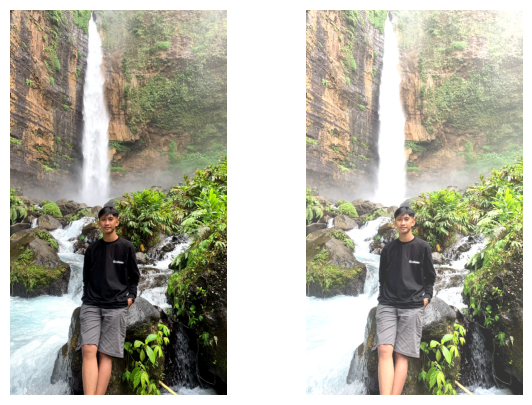

In [53]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive')

print('Mengubah tingkat kecerahan dan kontras citra')
print('--------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/aktivitas.jpeg')

brightness_image = np.zeros(original.shape, original.dtype)

#akses per pixel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-25500)
for y in range (original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(int(original[y,x,c])+brightness, 0, 255)

#cara simpel tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
brightness_rgb = cv.cvtColor(brightness_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))

plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(brightness_rgb)
plt.axis('off')

plt.show()


# **TUGAS PRAKTIKUM**

# **1**

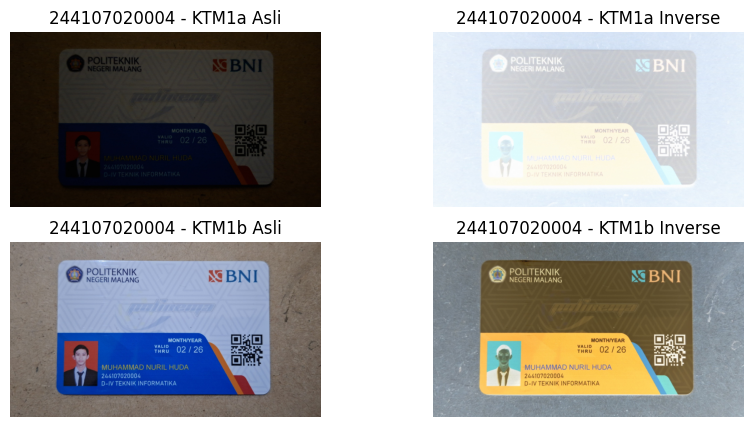

In [54]:
KTM1a = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/KTM1a.jpg')
KTM1b = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/KTM1b.jpg')

KTM1a_risize =  cv.resize(
    KTM1a,
    None,
    fx=0.5,
    fy=0.5
)

KTM1b_risize =  cv.resize(
    KTM1b,
    None,
    fx=0.5,
    fy=0.5
)


inverse1 = 255 - KTM1a_risize
inverse2 = 255 - KTM1b_risize

KTM1a_rgb = cv.cvtColor(KTM1a_risize, cv.COLOR_BGR2RGB)
KTM1b_rgb = cv.cvtColor(KTM1b_risize, cv.COLOR_BGR2RGB)
inverse1 = cv.cvtColor(inverse1, cv.COLOR_BGR2RGB)
inverse2 = cv.cvtColor(inverse2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(KTM1a_rgb)
plt.title(NIM + ' - KTM1a Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(inverse1)
plt.title(NIM + ' - KTM1a Inverse')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(KTM1b_rgb)
plt.title(NIM + ' - KTM1b Asli')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(inverse2)
plt.title(NIM + ' - KTM1b Inverse')
plt.axis('off')

plt.show()




Hasil KTM1a terlihat lebih pucat karena citra asli diambil pada kondisi pencahayaan yang gelap sehingga sebagian pixel memiliki intensitas rendah. Setelah dibalik, area yang semula gelap berubah menjadi terang dan menyebabkan kontras terlihat menurun. Sedangkan untuk KTM1b memiliki pencahayaan yang lebih baik sehingga distribusi intensitas lebih merata

# **2**

Mengubah tingkat kecerahan dan kontras citra
--------------------------------
Masukkan nilai kecerahan: 10


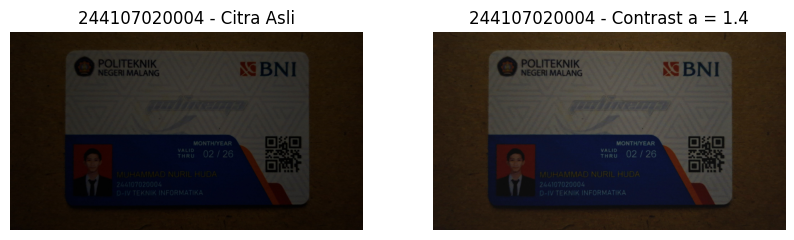

In [55]:

print('Mengubah tingkat kecerahan dan kontras citra')
print('--------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

contrast_image = np.zeros(
    KTM1a_risize.shape,
    KTM1a_risize.dtype
)

a = PARAM['a']

for y in range(KTM1a_risize.shape[0]):
    for x in range(KTM1a_risize.shape[1]):
        for c in range(KTM1a_risize.shape[2]):

            contrast_image[y,x,c] = np.clip( int(KTM1a_risize[y,x,c]) * a + brightness, 0, 255)

contrast_rgb = cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(KTM1a_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(contrast_rgb)
plt.title(NIM + f' - Contrast a = {a}')
plt.axis('off')

plt.show()

# **3**

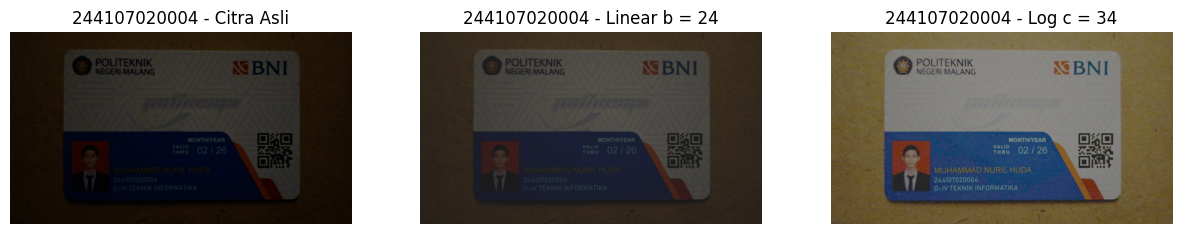

In [56]:
#Linear Brightness
linear_image = np.zeros(
    KTM1a_risize.shape,
    KTM1a_risize.dtype
)

b = PARAM['b']

for y in range(KTM1a_risize.shape[0]):
    for x in range(KTM1a_risize.shape[1]):
        for c in range(KTM1a_risize.shape[2]):

            linear_image[y,x,c] = np.clip( int(KTM1a_risize[y,x,c]) + b, 0, 255)



#Logarithmic Brightness
log_image = np.zeros(
    KTM1a_risize.shape,
    KTM1a_risize.dtype
)

c = PARAM['c']

for y in range(KTM1a_risize.shape[0]):
    for x in range(KTM1a_risize.shape[1]):
        for ch in range(KTM1a_risize.shape[2]):
            log_image[y,x,ch] = np.clip( c * np.log(1 + int(KTM1a_risize[y,x,ch])), 0, 255)

linear_rgb = cv.cvtColor(linear_image, cv.COLOR_BGR2RGB)
log_rgb = cv.cvtColor(log_image, cv.COLOR_BGR2RGB)


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(KTM1a_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(linear_rgb)
plt.title(NIM + f' - Linear b = {b}')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_rgb)
plt.title(NIM + f' - Log c = {c}')
plt.axis('off')

plt.show()



Metode Logarithmic Brightness memberikan hasil terbaik untuk memperjelas NIM pada kartu mahasiswa karena mampu meningkatkan kecerahan pada area gelap secara lebih efektif. Namun, metode ini juga berpotensi menyebabkan clipping pada bagian yang sudah terang. Sebaliknya, metode Linear Brightness menghasilkan peningkatan kecerahan yang lebih merata dan minim clipping, tetapi detail NIM masih kurang jelas dibandingkan metode logaritmik.

# **4**

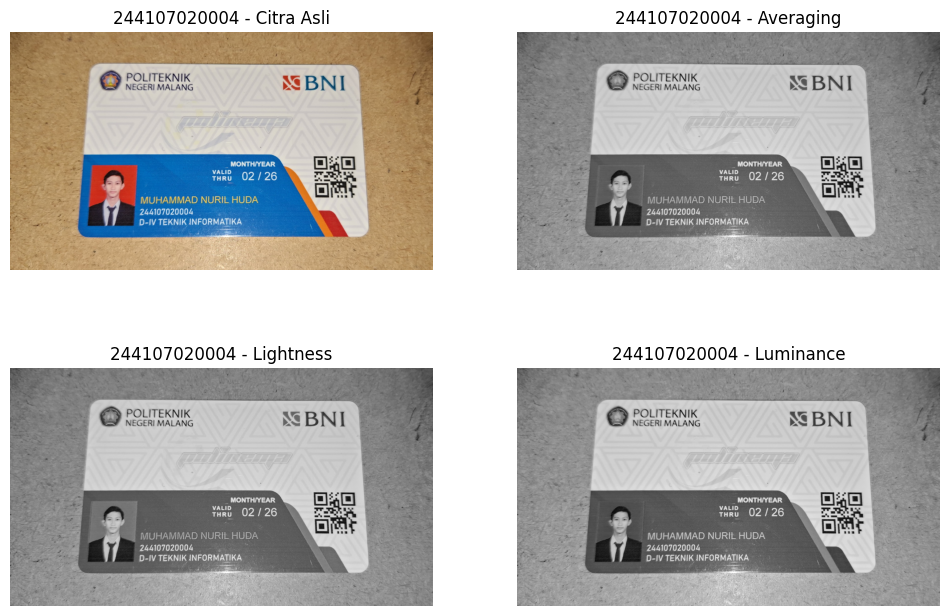

=== Statistik Grayscale ===

Averaging
Mean : 148.62523801481782
Std  : 41.97654006686007

Lightness
Mean : 147.62549778454454
Std  : 42.1359856586131

Luminance
Mean : 151.21877252035938
Std  : 43.655804843229596


In [57]:
KTM1c = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/KTM1c.jpg')
KTM1c_resize = cv.resize(KTM1c, None, fx=0.5, fy=0.5)


#Metode Averaging

gray_avg = np.zeros(KTM1c_resize.shape[:2], dtype=np.uint8)

for y in range(KTM1c_resize.shape[0]):
    for x in range(KTM1c_resize.shape[1]):

        b = KTM1c_resize[y,x,0]
        g = KTM1c_resize[y,x,1]
        r = KTM1c_resize[y,x,2]

        gray_avg[y,x] = int((int(r)+int(g)+int(b))/3)


#Metode Lightness

gray_light = np.zeros(KTM1c_resize.shape[:2], dtype=np.uint8)

for y in range(KTM1c_resize.shape[0]):
    for x in range(KTM1c_resize.shape[1]):

        b = KTM1c_resize[y,x,0]
        g = KTM1c_resize[y,x,1]
        r = KTM1c_resize[y,x,2]

        maksimum = max(r,g,b)
        minimum = min(r,g,b)

        gray_light[y,x] = int((int(maksimum)+int(minimum))/2)

#Metode Luminace

gray_luminance = np.zeros(KTM1c_resize.shape[:2], dtype=np.uint8)

for y in range(KTM1c_resize.shape[0]):
    for x in range(KTM1c_resize.shape[1]):

        b = KTM1c_resize[y,x,0]
        g = KTM1c_resize[y,x,1]
        r = KTM1c_resize[y,x,2]

        gray_luminance[y,x] = (
            0.21 * r +
            0.72 * g +
            0.07 * b
        )

KTM1c_rgb = cv.cvtColor(KTM1c_resize, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(KTM1c_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gray_avg, cmap='gray')
plt.title(NIM + ' - Averaging')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(gray_light, cmap='gray')
plt.title(NIM + ' - Lightness')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(gray_luminance, cmap='gray')
plt.title(NIM + ' - Luminance')
plt.axis('off')

plt.show()

print("=== Statistik Grayscale ===")

print("\nAveraging")
print("Mean :", np.mean(gray_avg))
print("Std  :", np.std(gray_avg))

print("\nLightness")
print("Mean :", np.mean(gray_light))
print("Std  :", np.std(gray_light))

print("\nLuminance")
print("Mean :", np.mean(gray_luminance))
print("Std  :", np.std(gray_luminance))

Berdasarkan hasil perhitungan, metode Luminance memiliki nilai rata-rata intensitas tertinggi yaitu 151,22 dan nilai standar deviasi terbesar yaitu 43,66. Nilai standar deviasi yang lebih besar menunjukkan bahwa perbedaan intensitas antara area terang dan gelap lebih jelas sehingga kontras citra menjadi lebih baik. Metode Averaging menghasilkan mean 148,63 dan standar deviasi 41,98, sedangkan metode Lightness menghasilkan mean 147,63 dan standar deviasi 42,14. Kedua metode tersebut memiliki kontras yang sedikit lebih rendah dibandingkan metode Luminance. Dengan demikian, metode Luminance memberikan pemisahan paling jelas antara teks dan latar belakang kartu, sehingga tulisan pada kartu, termasuk NIM, lebih mudah dibaca dibandingkan metode Averaging dan Lightness

# **5**

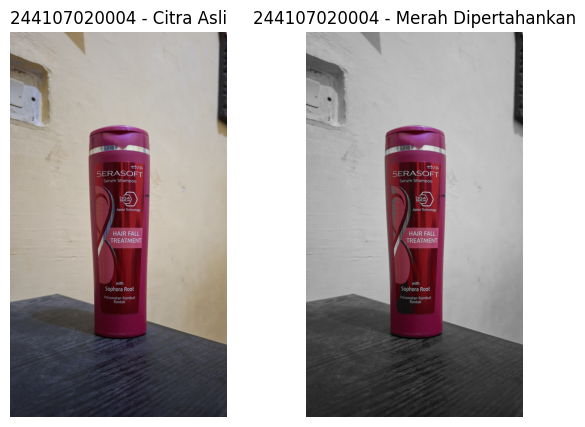

In [58]:
OBJ1 = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/OBJ1.jpg')
OBJ1_resize = cv.resize(OBJ1,None,fx=0.5, fy=0.5)

hsv = cv.cvtColor(OBJ1_resize,cv.COLOR_BGR2HSV)

lower = np.array([140, 50, 50])
upper = np.array([180, 255, 255])

mask = cv.inRange(hsv,lower,upper)

gray = cv.cvtColor(OBJ1_resize,cv.COLOR_BGR2GRAY)

gray = cv.cvtColor(gray,cv.COLOR_GRAY2BGR)

result = np.where(
    mask[:,:,None] == 255,
    OBJ1_resize,
    gray
)

OBJ1_rgb = cv.cvtColor(OBJ1_resize,cv.COLOR_BGR2RGB)

result_rgb = cv.cvtColor(result,cv.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))

plt.subplot(1,2,1)
plt.imshow(OBJ1_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result_rgb)
plt.title(NIM + ' - Merah Dipertahankan')
plt.axis('off')

plt.show()



Warna merah dipertahankan menggunakan rentang HSV [140, 50, 50] hingga [180, 255, 255], sedangkan bagian lainnya diubah menjadi grayscale. Hasilnya, objek utama terlihat lebih menonjol dibanding latar belakang. Saat rentang HSV dipersempit, sebagian warna merah tidak terdeteksi sehingga beberapa bagian botol menjadi abu-abu. Sebaliknya, saat rentang diperlebar, lebih banyak area merah terdeteksi, tetapi warna lain yang mirip merah juga dapat ikut terpilih.

# **6**

Gamma Corection Pada Citra
--------------------------
Masukkan nilai gamma: 2.5


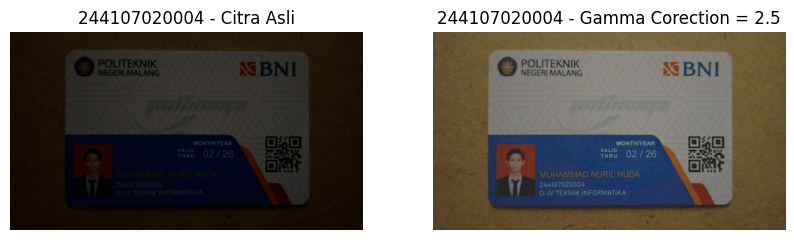

In [59]:
print('Gamma Corection Pada Citra')
print('--------------------------')
try:
  gamma = float(input('Masukkan nilai gamma: '))
except ValueError:
  print('Error, not a number')

gamma_image = np.zeros(
    KTM1a_risize.shape,
    KTM1a_risize.dtype
)

for y in range(KTM1a_risize.shape[0]):
    for x in range(KTM1a_risize.shape[1]):
        for c in range(KTM1a_risize.shape[2]):

            gamma_image[y,x,c] = np.clip(255 * ((KTM1a_risize[y,x,c] / 255) ** (1/gamma)), 0, 255)

gamma_rgb = cv.cvtColor(gamma_image,cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(KTM1a_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_rgb)
plt.title(NIM + f' - Gamma Corection = {gamma}')
plt.axis('off')

plt.show()

Nilai gamma terbaik yang saya pilih adalah gamma = 2.5, karena pada nilai tersebut nama dan NIM terlihat paling jelas dan mudah dibaca. Nilai gamma terbaik setiap mahasiswa dapat berbeda karena kondisi pencahayaan, kualitas gambar, dan tingkat kecerahan awal setiap foto tidak sama. Oleh karena itu, nilai gamma yang menghasilkan tampilan terbaik juga dapat berbeda.

# **7**

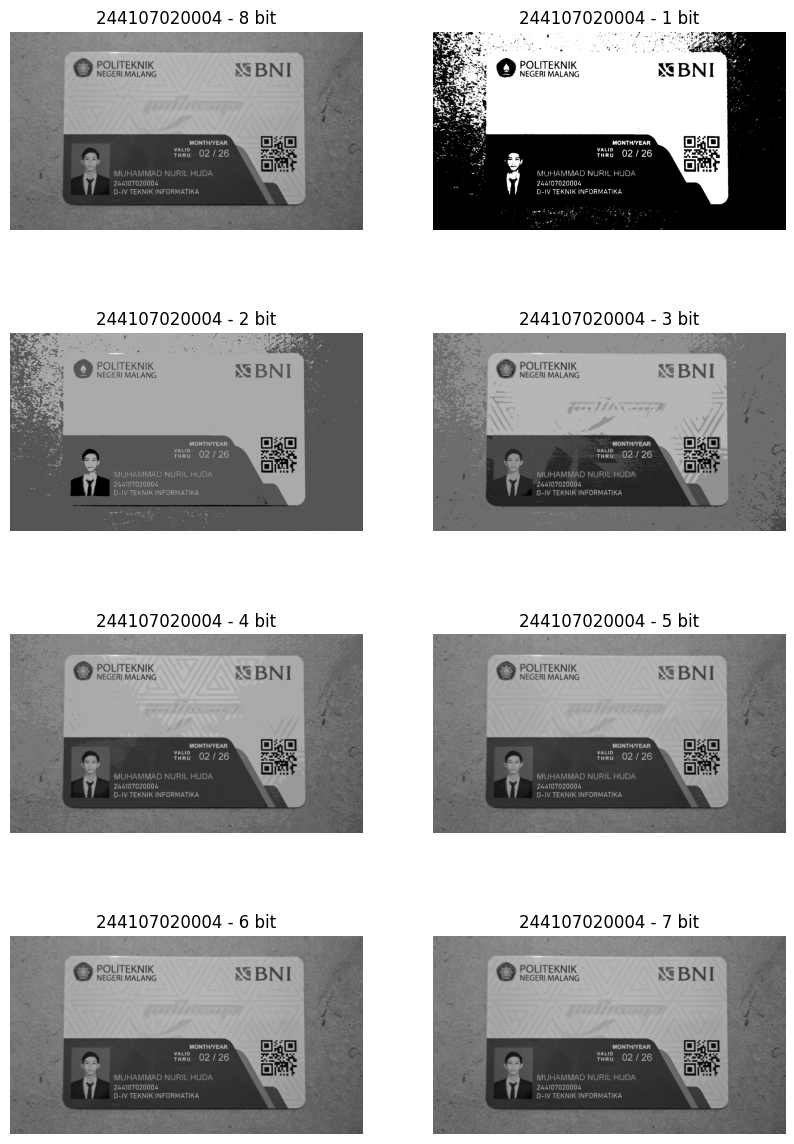

In [61]:
KTM1b_gray = cv.cvtColor(KTM1b_risize,cv.COLOR_BGR2GRAY)

plt.figure(figsize=(10,15))

plt.subplot(4,2,1)
plt.imshow(KTM1b_gray, cmap='gray')
plt.title(NIM + f' - 8 bit')
plt.axis('off')

for bit_depth in range(1,8):

    level = 255 / (pow(2, bit_depth) - 1)

    depth_image = np.round(KTM1b_gray / level) * level

    depth_image = depth_image.astype(np.uint8)

    plt.subplot(4,2,bit_depth+1)
    plt.imshow(depth_image, cmap='gray')
    plt.title(NIM + f' - {bit_depth} bit')
    plt.axis('off')

plt.show()


Nama dan NIM masih dapat dibaca pada seluruh kedalaman bit

# **8**

Jumlah gambar : 100
10 gambar  PSNR = 19.57 dB
20 gambar  PSNR = 19.68 dB
40 gambar  PSNR = 19.73 dB
80 gambar  PSNR = 19.76 dB
100 gambar  PSNR = 19.76 dB


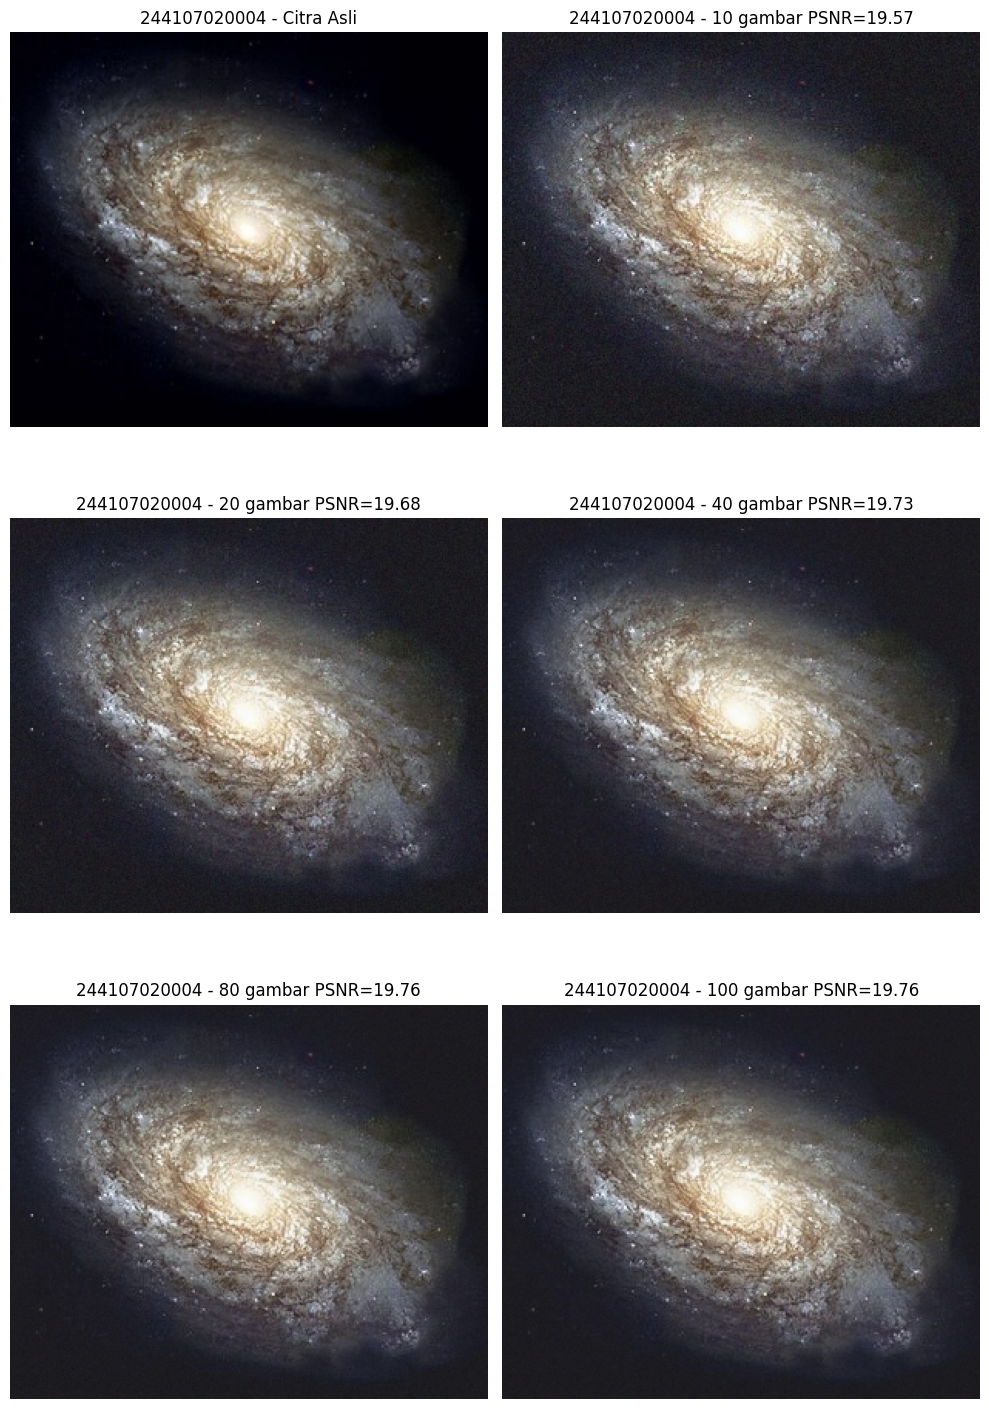

In [62]:
import glob

cv_img = []
for img in glob.glob('/content/drive/MyDrive/Semester 5/PCVK/images/noises/*.jpg'):
    n = cv.imread(img)
    cv_img.append(n)

print('Jumlah gambar :', len(cv_img))

galaxy = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/galaxy.jpg')
galaxy = cv.resize(galaxy,(cv_img[0].shape[1], cv_img[0].shape[0]))
galaxy_rgb = cv.cvtColor(galaxy,cv.COLOR_BGR2RGB)

#Membuat fungsi averange denoising
def average_denoising(images, jumlah):

    avg = np.zeros(images[0].shape, dtype=np.float64)

    for i in range(jumlah):
        avg += images[i]

    avg = avg / jumlah

    return avg.astype(np.uint8)

#Membuat fungsi psnr
def hitung_psnr(img1, img2):

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mse = np.mean((img1 - img2) ** 2)

    if mse == 0: return 100

    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr

jumlah_list = [10,20,40,80,100]

hasil_list = []
psnr_list = []

for jumlah in jumlah_list:

    hasil = average_denoising(
        cv_img,
        jumlah
    )

    psnr = hitung_psnr(
        galaxy,
        hasil
    )

    hasil_list.append(hasil)
    psnr_list.append(psnr)

    print(
        f'{jumlah} gambar  PSNR = {psnr:.2f} dB'
    )

plt.figure(figsize=(10,15))

plt.subplot(3,2,1)
plt.imshow(galaxy_rgb)
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

for i in range(len(hasil_list)):

    hasil_rgb = cv.cvtColor(
        hasil_list[i],
        cv.COLOR_BGR2RGB
    )

    plt.subplot(3,2,i+2)
    plt.imshow(hasil_rgb)
    plt.title(NIM + f' - {jumlah_list[i]} gambar PSNR={psnr_list[i]:.2f}')
    plt.axis('off')

plt.tight_layout()
plt.show()

1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak. Semakin banyak citra yang digunakan untuk averaging, nilai PSNR memang meningkat, tetapi peningkatannya semakin kecil. Dari 10 hingga 40 citra masih terlihat kenaikan, sedangkan setelah itu kenaikannya sangat kecil.

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Peningkatan mulai tidak terlalu signifikan pada sekitar 80 citra, karena nilai PSNR pada 80 citra dan 100 citra sama-sama sekitar 19.76 dB. Hal ini menunjukkan bahwa penambahan citra setelah 80 buah tidak memberikan peningkatan kualitas yang berarti.

nb: Gambar galaxy yang asli saya ambil dari google karena file tersebut tidak tersedia pada folder images. Oleh karena itu, hasil PSNR mungkin sedikit dipengaruhi oleh perbedaan ukuran atau kualitas gambar.

# **9**

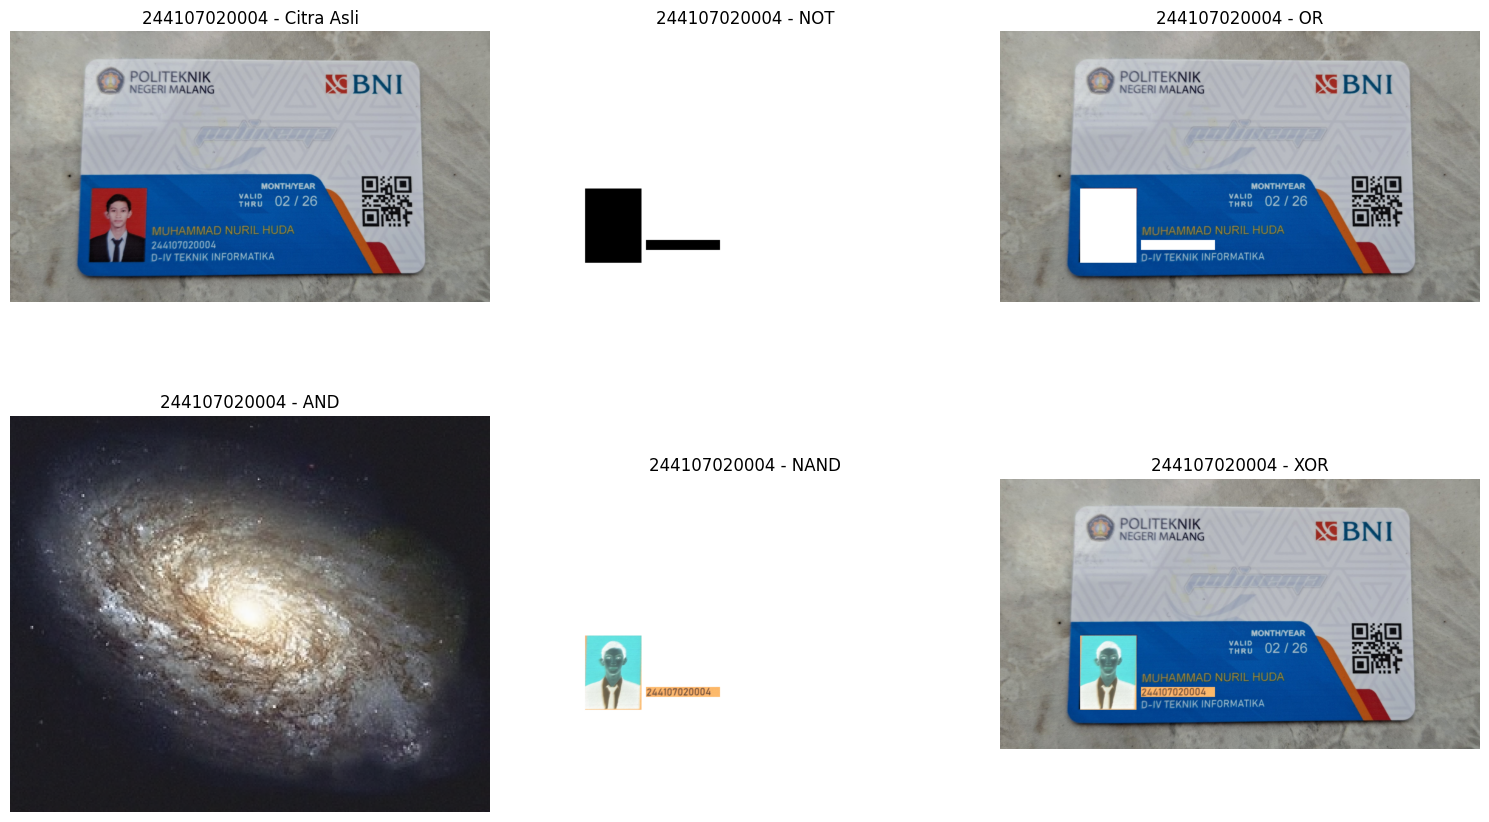

In [63]:
KTM1d = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/KTM1d.jpg')
KTM1d_resize = cv.resize(KTM1d,None,fx=0.5, fy=0.5)

mask = np.zeros(KTM1d_resize.shape[:2], dtype=np.uint8)

# Mask foto
cv.rectangle(
    mask,
    (250,490),
    (425,720),
    255,
    -1
)

# Mask NIM
cv.rectangle(
    mask,
    (440,650),
    (670,680),
    255,
    -1
)

hasil_and = cv.bitwise_and(
    KTM1d_resize,
    KTM1d_resize,
    mask=cv.bitwise_not(mask)
)

hasil_not = cv.bitwise_not(mask)

mask_bgr = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

hasil_or = cv.bitwise_or(
    KTM1d_resize,
    mask_bgr
)

hasil_nand = cv.bitwise_not(
    cv.bitwise_and(
        KTM1d_resize,
        mask_bgr
    )
)

hasil_xor = cv.bitwise_xor(
    KTM1d_resize,
    mask_bgr
)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(cv.cvtColor(KTM1d_resize,cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(hasil_not, cmap='gray')
plt.title(NIM + ' - NOT')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(cv.cvtColor(hasil_or,cv.COLOR_BGR2RGB))
plt.title(NIM + ' - OR')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(cv.cvtColor(hasil,cv.COLOR_BGR2RGB))
plt.title(NIM + ' - AND')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv.cvtColor(hasil_nand,cv.COLOR_BGR2RGB))
plt.title(NIM + ' - NAND')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(cv.cvtColor(hasil_xor,cv.COLOR_BGR2RGB))
plt.title(NIM + ' - XOR')
plt.axis('off')

plt.tight_layout()
plt.show()

Hasil operator NOT menghasilkan kebalikan dari mask, sehingga area yang semula putih menjadi hitam dan sebaliknya. Operator OR membuat area yang terkena mask menjadi lebih terang karena digabungkan dengan nilai putih pada mask. Operator AND berhasil menutupi area foto dan NIM dengan warna hitam sehingga data pribadi tidak terlihat. Operator NAND menghasilkan kebalikan dari AND sehingga warna pada area yang diproses tampak seperti negatif (invers). Operator XOR menampilkan perbedaan antara citra dan mask sehingga area foto dan NIM berubah warna secara mencolok.

# **10**

Masukkan nilai gamma: 2
Masukkan nilai b: 10
Masukkan nilai a: 2


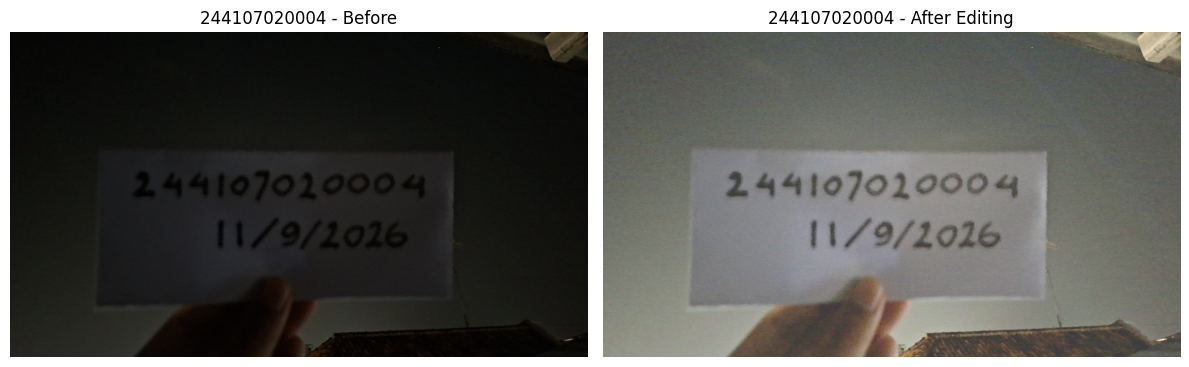

In [64]:
NIGHT1 = cv.imread('/content/drive/MyDrive/Semester 5/PCVK/images/244107020004/NIGHT1.jpg')
NIGHT1_resize = cv.resize(NIGHT1,None,fx=0.5, fy=0.5)

try:
  gamma = float(input('Masukkan nilai gamma: '))
except ValueError:
  print('Error, not a number')

try:
  b = float(input('Masukkan nilai b: '))
except ValueError:
  print('Error, not a number')

try:
  a = float(input('Masukkan nilai a: '))
except ValueError:
  print('Error, not a number')

# try:
#   c = float(input('Masukkan nilai c: '))
# except ValueError:
#   print('Error, not a number')


# #Linear Brightness
# linear_image = np.zeros(
#     NIGHT1_resize.shape,
#     NIGHT1_resize.dtype
# )
# for y in range(NIGHT1_resize.shape[0]):
#     for x in range(NIGHT1_resize.shape[1]):
#         for c in range(NIGHT1_resize.shape[2]):

#             linear_image[y,x,c] = np.clip( int(NIGHT1_resize[y,x,c]) + b, 0, 255)


# #Logarithmic Brightness
# log_image = np.zeros(
#     linear_image.shape,
#     linear_image.dtype
# )
# for y in range(linear_image.shape[0]):
#     for x in range(linear_image.shape[1]):
#         for ch in range(linear_image.shape[2]):
#             log_image[y,x,ch] = np.clip( c * np.log(1 + int(linear_image[y,x,ch])), 0, 255)

#Contrast
contrast_image = np.zeros(
    NIGHT1_resize.shape,
    NIGHT1_resize.dtype
)
for y in range(NIGHT1_resize.shape[0]):
    for x in range(NIGHT1_resize.shape[1]):
        for c in range(NIGHT1_resize.shape[2]):
            contrast_image[y,x,c] = np.clip( int(NIGHT1_resize[y,x,c]) * a + b, 0, 255)

#Gamma Correction
gamma_image = np.zeros(
    contrast_image.shape,
    contrast_image.dtype
)
for y in range(contrast_image.shape[0]):
    for x in range(contrast_image.shape[1]):
        for c in range(contrast_image.shape[2]):

            gamma_image[y,x,c] = np.clip(255 * ((contrast_image[y,x,c] / 255) ** (1/gamma)), 0, 255)



NIGHT1_rgb = cv.cvtColor(NIGHT1_resize,cv.COLOR_BGR2RGB)

gamma_rgb = cv.cvtColor(gamma_image,cv.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(NIGHT1_rgb)
plt.title(NIM + ' - Before')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_rgb)
plt.title(NIM + ' - After Editing')
plt.axis('off')

plt.tight_layout()
plt.show()

**1. Metode Yang Dipilih**

Pada percobaan ini saya menggunakan metode Gamma Correction dan Contrast untuk memperbaiki kualitas foto malam yang gelap.


**2. Alasan Pemilihan**

Saya memilih Gamma Correction karena metode ini dapat membuat bagian gambar yang gelap menjadi lebih terang sehingga detail objek lebih mudah terlihat. Setelah itu saya menggunakan Contrast untuk memperjelas perbedaan antara bagian terang dan gelap agar gambar terlihat lebih jelas.


**3. Menentukan Parameter Terbaik**

Saya menentukan parameter terbaik dengan cara mencoba beberapa nilai secara satu per satu dan membandingkan hasilnya. Dari beberapa percobaan yang dilakukan, saya memilih gamma = 2, a = 2, dan b = 10 karena menghasilkan gambar yang lebih terang dan detail objek lebih mudah dilihat dibandingkan parameter lainnya. Selain itu, hasil gambar masih terlihat cukup alami dan tidak terlalu terang.